#10-09-2026

#Applied Statistics

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


**What is the probability, a person visit the billing counter to pay the bill is a Male?**

In [ ]:
tips['sex'].value_counts()

,count
sex,
Male,157
Female,87


In [ ]:
tips['sex'].value_counts(normalize=True)

,proportion
sex,
Male,0.643443
Female,0.356557


In [ ]:
tips['smoker'].value_counts(normalize=True)

,proportion
smoker,
No,0.618852
Yes,0.381148


Are the variables sex and smoker Independent?
- Is the variable sex effects variables smoker?

In [ ]:
ct=pd.crosstab(tips['sex'],tips['smoker'],margins=True,normalize= True)
ct

smoker,Yes,No,All
sex,,,
Male,0.245902,0.397541,0.643443
Female,0.135246,0.221311,0.356557
All,0.381148,0.618852,1.000000


In [ ]:
ct['All']

,All
sex,
Male,0.643443
Female,0.356557
All,1.000000


In [ ]:
ct.apply(lambda x: x/ct['All'])

smoker,Yes,No,All
sex,,,
Male,0.382166,0.617834,1.0
Female,0.379310,0.620690,1.0
All,0.381148,0.618852,1.0


#11-09-2026

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**What is the relationship between smoker and time?**
- Are smokers prefer visting restaurent during lunch time or dinner time. Thereby restaurent will plan cigerettes accordingly.

In [ ]:
tips['smoker'].value_counts()

,count
smoker,
No,151
Yes,93


In [ ]:
tips['smoker'].value_counts(normalize=True)

,proportion
smoker,
No,0.618852
Yes,0.381148


- p(smoker) = 0.38
- p(non-smoker) = 0.62

In [ ]:
tips['time'].value_counts(normalize = True)

,proportion
time,
Dinner,0.721311
Lunch,0.278689


- p(a person visit during lunch) - 0.28
- p(a person visit during dinner) - 0.72

In [ ]:
ct = pd.crosstab(tips['smoker'], tips['time'])
ct

time,Lunch,Dinner
smoker,,
Yes,23,70
No,45,106


In [ ]:
ct = pd.crosstab(tips['smoker'], tips['time'], margins = True, normalize = True)
ct

time,Lunch,Dinner,All
smoker,,,
Yes,0.094262,0.286885,0.381148
No,0.184426,0.434426,0.618852
All,0.278689,0.721311,1.000000


In [ ]:
cond_prob = ct.apply(lambda x: x/ct['All'])
cond_prob

time,Lunch,Dinner,All
smoker,,,
Yes,0.247312,0.752688,1.0
No,0.298013,0.701987,1.0
All,0.278689,0.721311,1.0


- p(L/SM) = 0.247 and p(L) = 0.278
- p(D/SM) = 0.753 and p(D) = 0.72
- p(L/NS) = 0.298 and p(L) = 0.278
- p(D/NS) = 0.702 and p(D) = 0.72

- More chance that
  - Smokers visits the restaurent during Dinner time
    - p(D/SM) > p(L/NS)
  - Non Smokers visits restaurent during Lunch time
    - p(L/SM) < p(L/NS)

Binomial Distribution

In [ ]:
import scipy.stats as st

In [ ]:
st.binom.pmf(5, 10, 0.62)

np.float64(0.18292664591166624)

In [ ]:
st.binom.cdf(5, 10, 0.62)

np.float64(0.3176869791984085)

#15-09-2026

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns

In [ ]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
tips['sex']

,sex
0,Female
1,Male
2,Male
3,Male
4,Female
...,...
239,Male
240,Female
241,Male
242,Male


In [ ]:
# 244 is a fairly large number
tips['sex'].value_counts()

,count
sex,
Male,157
Female,87


`P(Female)` = 0.36

Frequency approach - Relative frequency Approximation to probability

In [ ]:
# P(5 visitors are female out of 10 people visits the restaurent)
# P(X = 5)
st.binom.pmf(k =5, n = 10, p = 0.36)

np.float64(0.16361115651353336)

In [ ]:
# P(ATMOST 5 visitors are female out of 10 people visits the restaurent)
# P(X = 5)
# P(X = 0) + P(X = 1)+ P(X = 2) + P(X = 3) + P(X = 4) + P(X = 5)
st.binom.cdf(k = 5, n = 10, p = 0.36)

np.float64(0.8927696207764416)

In [ ]:
cum_prob = 0
for i in range(6):
  cum_prob += st.binom.pmf(k = i, n = 10, p = 0.36)
cum_prob

np.float64(0.8927696207764415)

In [ ]:
# P(ATLEAST 5 visitors are female out of 10 people visits the restaurent)
# P(X >= 5)
# 1 - P(X <= 4)
1 - st.binom.cdf(k = 4, n = 10, p = 0.36)

np.float64(0.2708415357370918)

In [ ]:
cum_prob = 0
for i in range(5, 11):
  cum_prob += st.binom.pmf(k = i, n = 10, p = 0.36)
cum_prob

np.float64(0.2708415357370916)

Multinomial Distribution

In [ ]:
# 244 is a fairly large number
tips['day'].value_counts()

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


In [ ]:
# P(in a random week out of 10 people visits restaurent,
## 1 visit during Thursday,
## 1 visit during Friday,
## 5 visits during Saturday and
## 3 visits during sunday)
st.multinomial.pmf(x = [1, 1, 5, 3], n = 10, p =[0.25, 0.08, 0.36, 0.31])

np.float64(0.018157586320097306)

Poisson Distribution

In [ ]:
tips['size'].mean()

np.float64(2.569672131147541)

In [ ]:
tips['size'].var()

0.9045908385616921

With a small compromise in accuracy we will assume data following Poission Distribution

In [ ]:
# P(2 people as a group visits restaurent and occupies 6 seating table)
st.poisson.pmf(k = 2, mu = 2.57)

np.float64(0.2527548119851966)

In [ ]:
# P(ATMOST 2 people as a group visits restaurent and occupies 6 seating table)
# P(X <= 3)
st.poisson.cdf(k = 3, mu = 2.57)

np.float64(0.7425133314158789)

In [ ]:
cum_prob = 0
for i in range(4):
  cum_prob += st.poisson.pmf(k = i, mu = 2.57)
cum_prob

np.float64(0.7425133314158792)

In [ ]:
# P(ATLEAST 2 people as a group visits restaurent and occupies 6 seating table)
# P(X >= 3)
1 - st.poisson.cdf(k =2, mu = 2.57)

np.float64(0.47401329085143984)

In [ ]:
cum_prob = 0
for i in range(3, 1000):
  cum_prob += st.poisson.pmf(k = i, mu = 2.57)
cum_prob

np.float64(0.4740132908514395)

#16-09-2026

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = st.uniform.rvs(loc = 2, scale = 8, size = 1000, random_state = 42)
data

array([4.99632095, 9.60571445, 7.85595153, 6.78926787, 3.24814912,
       3.24795616, 2.4646689 , 8.92940917, 6.80892009, 7.66458062,
       2.16467595, 9.75927882, 8.65954113, 3.69871289, 3.45459974,
       3.46723608, 4.43393794, 6.19805145, 5.45556015, 4.32983312,
       6.89482316, 3.11595089, 4.33715719, 4.93089475, 5.64855987,
       8.28140769, 3.59739026, 6.11387551, 6.73931655, 2.3716033 ,
       6.86035882, 3.36419299, 2.52041274, 9.5910843 , 9.72505626,
       8.46717878, 4.43691015, 2.78137691, 7.47386421, 5.52121995,
       2.97630588, 5.96141528, 2.27510817, 9.27456322, 4.07023985,
       7.30017827, 4.49368861, 6.16054417, 6.37368223, 3.47883564,
       9.75667702, 8.20106259, 9.51599153, 9.1586188 , 6.78319983,
       9.37499388, 2.70794002, 3.5678629 , 2.36181831, 4.60264265,
       5.10941832, 4.17079225, 8.62990007, 4.85402661, 4.24747608,
       6.34156867, 3.1273938 , 8.41757585, 2.59640515, 9.89509549,
       8.17795815, 3.58972545, 2.04417694, 8.52369143, 7.65485

<Axes: ylabel='Count'>

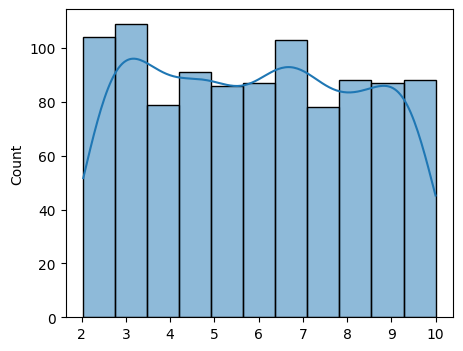

In [ ]:
plt.figure(figsize = (5,4))
sns.histplot(data, kde = True)

In [ ]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: ylabel='Density'>

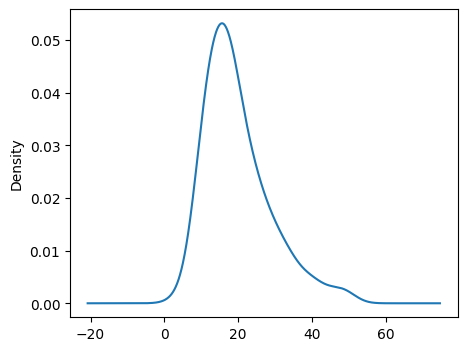

In [ ]:
tips['total_bill'].plot(kind = 'kde', figsize = (5,4))

In [ ]:
tips['total_bill'].skew()

np.float64(1.1332130376158205)

In [ ]:
tips['total_bill'].kurtosis()

np.float64(1.2184840156638854)

In [ ]:
log_tb = np.log(tips['total_bill'])

<Axes: ylabel='Density'>

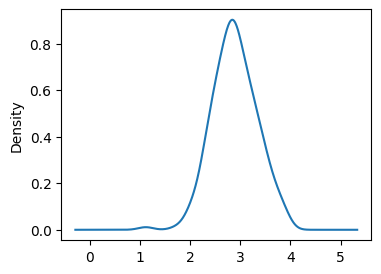

In [ ]:
log_tb.plot(kind = 'kde', figsize = (4, 3))

In [ ]:
log_tb.skew()

np.float64(-0.11623079290253824)

In [ ]:
log_tb.kurtosis()

np.float64(0.4734793671474513)

#17-09-2026

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**Simple Random Sampling**

In [ ]:
# Sample size = 40
tips.sample(n = 40)

,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
193,15.48,2.02,Male,Yes,Thur,Lunch,2
25,17.81,2.34,Male,No,Sat,Dinner,4
17,16.29,3.71,Male,No,Sun,Dinner,3
79,17.29,2.71,Male,No,Thur,Lunch,2
145,8.35,1.50,Female,No,Thur,Lunch,2
113,23.95,2.55,Male,No,Sun,Dinner,2
233,10.77,1.47,Male,No,Sat,Dinner,2
190,15.69,1.50,Male,Yes,Sun,Dinner,2
183,23.17,6.50,Male,Yes,Sun,Dinner,4


**Stratified Random Sampling**

In [ ]:
tips.groupby('sex')

/tmp/ipykernel_2856/1355517733.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby('sex')


In [ ]:
tips.groupby('sex').sample(20)

/tmp/ipykernel_2856/162238020.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby('sex').sample(20)


,total_bill,tip,sex,smoker,day,time,size
47,32.40,6.00,Male,No,Sun,Dinner,4
107,25.21,4.29,Male,Yes,Sat,Dinner,2
76,17.92,3.08,Male,Yes,Sat,Dinner,2
218,7.74,1.44,Male,Yes,Sat,Dinner,2
20,17.92,4.08,Male,No,Sat,Dinner,2
181,23.33,5.65,Male,Yes,Sun,Dinner,2
177,14.48,2.00,Male,Yes,Sun,Dinner,2
45,18.29,3.00,Male,No,Sun,Dinner,2
228,13.28,2.72,Male,No,Sat,Dinner,2
166,20.76,2.24,Male,No,Sun,Dinner,2


**Systematic Sampling**

In [ ]:
# Sample size = 40
tips.shape[0]

244

In [ ]:
tips.shape[0]//40

6

In [ ]:
tips[0::6]

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
6,8.77,2.00,Male,No,Sun,Dinner,2
12,15.42,1.57,Male,No,Sun,Dinner,2
18,16.97,3.50,Female,No,Sun,Dinner,3
24,19.82,3.18,Male,No,Sat,Dinner,2
30,9.55,1.45,Male,No,Sat,Dinner,2
36,16.31,2.00,Male,No,Sat,Dinner,3
42,13.94,3.06,Male,No,Sun,Dinner,2
48,28.55,2.05,Male,No,Sun,Dinner,3
54,25.56,4.34,Male,No,Sun,Dinner,4


In [ ]:
np.choose(1, range(1, 7))

np.int64(2)

- 0 - 5 : 1
- 6 - 11 : 7
- 12 - 17 : 13

In [ ]:
tips[1::6]

,total_bill,tip,sex,smoker,day,time,size
1,10.34,1.66,Male,No,Sun,Dinner,3
7,26.88,3.12,Male,No,Sun,Dinner,4
13,18.43,3.00,Male,No,Sun,Dinner,4
19,20.65,3.35,Male,No,Sat,Dinner,3
25,17.81,2.34,Male,No,Sat,Dinner,4
31,18.35,2.50,Male,No,Sat,Dinner,4
37,16.93,3.07,Female,No,Sat,Dinner,3
43,9.68,1.32,Male,No,Sun,Dinner,2
49,18.04,3.00,Male,No,Sun,Dinner,2
55,19.49,3.51,Male,No,Sun,Dinner,2


Assumption

In [ ]:
sample_srs = tips.sample(n = 40)
sample_srs

,total_bill,tip,sex,smoker,day,time,size
36,16.31,2.00,Male,No,Sat,Dinner,3
225,16.27,2.50,Female,Yes,Fri,Lunch,2
73,25.28,5.00,Female,Yes,Sat,Dinner,2
174,16.82,4.00,Male,Yes,Sun,Dinner,2
46,22.23,5.00,Male,No,Sun,Dinner,2
75,10.51,1.25,Male,No,Sat,Dinner,2
76,17.92,3.08,Male,Yes,Sat,Dinner,2
231,15.69,3.00,Male,Yes,Sat,Dinner,3
44,30.40,5.60,Male,No,Sun,Dinner,4
148,9.78,1.73,Male,No,Thur,Lunch,2


In [ ]:
sample_srs = tips.sample(n = 40)
sample_srs.head()

,total_bill,tip,sex,smoker,day,time,size
95,40.17,4.73,Male,Yes,Fri,Dinner,4
29,19.65,3.00,Female,No,Sat,Dinner,2
165,24.52,3.48,Male,No,Sun,Dinner,3
103,22.42,3.48,Female,Yes,Sat,Dinner,2
102,44.30,2.50,Female,Yes,Sat,Dinner,3


In [ ]:
# Sample Mean
sample_srs

#18-09-2026

Statistical Analysis
- Tips dataset
- Representative sample of all the restaurents available in the world
- Assuming level of confidence as 95% or level of significance as 5%
- alpha value is 5% - 0.05

If output probability (p)
- p < alpha - Reject the H0
- p > alpha - Unable to Reject the claim (Shouldn't Accept the H0)

In [1]:
import pandas as pd
import seaborn as sns
import scipy.stats as st

In [2]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**Claim on single Variable:** The Average total bill paid by customers of a Restaurent is $20

H0: mean = $20

H1: mean != $20

In [3]:
st.ttest_1samp(tips['total_bill'], 20)

AttributeError: module 'scipy.stats' has no attribute 'ttest_lsamp'

Result p(0.70) > 0.05
- Unable to Reject Null Hypothesis(mean is 20)
- Accepting the mean bill paid by customers in any restaurent is $20

**Claim on Categorical variable:** The proportion of smokers and non smokers is 50-50

H0: P(smoker) = 0.5

H1: P(Smoker) != 0.5

In [4]:
tips['smoker'].value_counts()

,count
smoker,
No,151
Yes,93


In [5]:
#chi square - gOODNES OF FIT TEST
st.chisquare(tips['smoker'].value_counts())

Power_divergenceResult(statistic=np.float64(13.78688524590164), pvalue=np.float64(0.00020476061287564678))

Result: p(0) < 0.05
- Reject the Null hypothesis
- The propoertion of smokers and non smokers are not same

**Claim on two Numeric variables:** Tip amd Total bill are correlated

DEFAULT HYPOTHESIS

H0: Variables are not correlated (rho = 0)

H1: varibles are correlated

<Axes: xlabel='tip', ylabel='total_bill'>

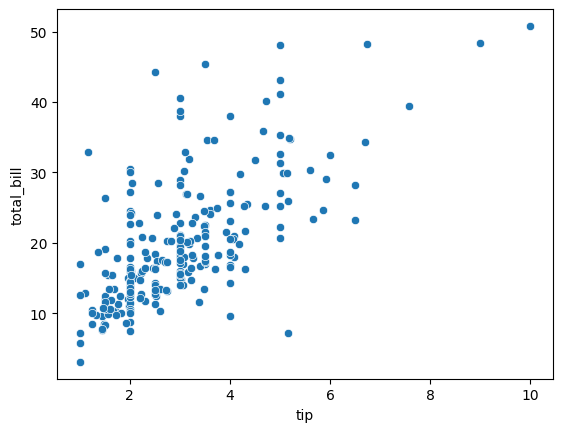

In [6]:
# Assumption - LINEAR RELATIONSHIP BETWEEN VARIABLES
sns.scatterplot(data = tips, x = 'tip', y = 'total_bill')

NameError: name 'total_bill' is not defined

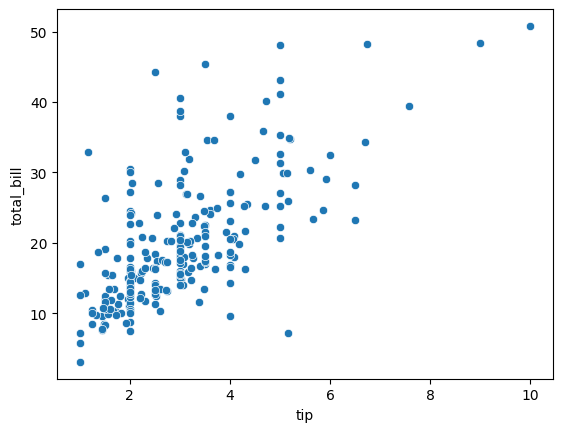

In [8]:
# Assumption - LINEAR RELATIONSHIP BETWEEN VARIABLES
sns.scatterplot(data = tips, x = 'tip', y = 'total_bill')
sns.scatterplot(data = tips, x = 'tip', y = 'total_bill')

In [9]:
# pearsonr test
st.pearsonr(tips['total_bill'], tips['tip'])

PearsonRResult(statistic=np.float64(0.6757341092113647), pvalue=np.float64(6.692470646863279e-34))

In [10]:
# spearmanr test
st.spearmanr(tips['total_bill'], tips['tip'])

SignificanceResult(statistic=np.float64(0.6789681219001009), pvalue=np.float64(2.501158440923619e-34))

Result: p(0) < 0.05
- Reject the null hypothesis (NOT CORRELATED)
- Tip and total bill are correlated

**Claim on two categorical Variables:** Sex and Smoker are independent

H0: Sex and Smoker are Independent

H1: Sex and Smoker are Dependent

In [11]:
ct = pd.crosstab(tips['sex'], tips['smoker'])
ct

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [12]:
# Chisquare test for independent
st.chi2_contigency(observed = ct)

AttributeError: module 'scipy.stats' has no attribute 'chi2_contigency'

Result p(1) > 0.05
- Unable to Reject Null Hypothesis (Independent)
- Sex and Smoker are Independent

**Claim on a numeric variable and a categorical variable:** Total bill paid by Smokers and Non smokers are same

H0: mean_tb_smokers = mean_tb_non_smokers

H1: mean_tb_smokers != mean_tb_non_smokers

In [13]:
# independent Samples t-test
## NORMALITY - Shapirowilk test
## Homoscedasticity - Levene test

In [14]:
tb_smokers = tips.loc[tips['smoker'] == 'yes', 'total_bill']
tb_non_smokers = tips.loc[tips['smoker'] == 'no', 'total_bill']

In [16]:
tb_non_smokers

,total_bill


In [15]:
tb_smokers

,total_bill


Nomality: DEFAULT HYPOTHESIS

H0: data is Normally Distributed

H1: Data is Not Normally Distributed

In [17]:
# Normality
st.shapiro(tb_smokers)

/tmp/ipykernel_4613/2188777521.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  st.shapiro(tb_smokers)


ShapiroResult(statistic=np.float64(nan), pvalue=np.float64(nan))

Result p(0) < 0.05
- Reject Null Hypothesis
- data is not normlaly distributed

**Because assumptions are not satisfied use a non parametric test names as : Mannwhitney U-test**

In [18]:
st.mannwhitneyu(tb_smokers, tb_non_smokers)

/tmp/ipykernel_4613/3098622672.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  st.mannwhitneyu(tb_smokers, tb_non_smokers)


MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))

Result: p(0.34) > 0.05
- Unable to reject Null Hypothesis
- Total bill paid by Smokers and Non smokers are same

**Claim on Multiple variables:** Average total bill paid by the customers during all the week days are same

H0: mea_tb_thrs = mean_tb_fri = mean_t_sat = mean_tb_sun

H1: mea_tb_thrs != mean_tb_fri = mean_t_sat != mean_tb_sun

In [19]:
# Oneway ANOVA
## normality - Shapiro wilk
## Homoscedasticity - Levene
### ASSUMING BOTH ARE SATISFIED

In [20]:
tips.day.unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [21]:
tb_thurs = tips.loc[tips['day'] == 'Thur', 'total_bill']
tb_fri = tips.loc[tips['day'] == 'Fri', 'total_bill']
tb_sat = tips.loc[tips['day'] == 'Sat', 'total_bill']
tb_sun = tips.loc[tips['day'] == 'Sun', 'total_bill']

In [24]:
# Oneway ANOVA
st.f_oneway(tb_thurs, tb_fri, tb_sat, tb_sun)

F_onewayResult(statistic=np.float64(2.767479443286335), pvalue=np.float64(0.04245383328952047))

Result: p(0.042) < 0.05
- reject the Null Hypothesis
- Mean total bill paid by customers during week days are not same

In [25]:
# ASSUMPTIONS ARE NOT SATISFIED
## kruskalWalls test
st.kruskal(tb_thurs, tb_fri, tb_sat, tb_sun)

KruskalResult(statistic=np.float64(10.403076391437086), pvalue=np.float64(0.01543300820104127))

Result: p(0.015) < 0.05
- reject the Null Hypothesis
- Mean total bill paid by customers during week days are not same